# This follows from the below workbook

https://github.com/adjtomo/adjdocs/blob/main/workshops/2024-05-21_scoped_uw/1_intro_specfem2d.ipynb

In [1]:
# Python packages we will use on our tour
import numpy as np
import matplotlib.pyplot as plt 
from IPython.display import Image
from seisflows.tools.model import Model

# Make sure we're in the correct directory
%cd /home/scoped/specfem2d
! ls

/home/scoped/specfem2d
AUTHORS        config.sub	flags.guess  OUTPUT_FILES	  utils
bin	       configure	install-sh   README.md		  VERSION
CITATION.cff   configure.ac	LICENSE      run_this_example.sh
config.guess   CONTRIBUTING.md	m4	     setup
config.log     DATA		Makefile     src
config.status  EXAMPLES		Makefile.in  tests


In [2]:
# Let's have a look at the executables
! ls bin

xadj_seismogram		      xconvolve_source_timefunction  xspecfem2D
xcheck_quality_external_mesh  xmeshfem2D		     xsum_kernels
xcombine_sem		      xsmooth_sem


In [3]:
! mpirun -n 1 bin/xcombine_sem

 Running XCOMBINE_SEM

 mpirun -n NPROC bin/xcombine_sem KERNEL_NAMES INPUT_FILE OUTPUT_DIR

 Please check command line arguments
 Error detected, aborting MPI... proc            0
application called MPI_Abort(MPI_COMM_WORLD, 30) - process 0


In [4]:
def print_pretty(text):
    """Makes it easier to distinguish print statement outputs"""
    print(f"\n{'='*80}\n {text:^80}\n{'='*80}\n")

# Look at the DATA/ directory
print_pretty("DATA/ DIRECTORY")
! ls DATA/

# Illustrates that the Par_file is an ASCII file with key-value pairs
print_pretty("PARAMETER FILE (Par_file)")
! head -38 DATA/Par_file

# The SPECFEM2D SOURCE file defines a 2D seismic source
print_pretty("SOURCE FILE (SOURCE)")
! head DATA/SOURCE
! echo "..."
! tail DATA/SOURCE

# Sometimes in SPECFEM2D, the Par_file defines station information directly
print_pretty("INTERNAL STATION DEFINITION (Par_file)")
! head -189 DATA/Par_file | tail -n 7

# However, other examples may define station information using STATIONS files, which is formatted:
print_pretty("EXTERNAL STATION DEFINITION (STATIONS)")
print("# STATION NETWORK X[m] Z[m] burial[m] elevation[m]")
! head -5 EXAMPLES/Tape2007/DATA/STATIONS_checker


                                 DATA/ DIRECTORY                                 

Par_file  SOURCE

                            PARAMETER FILE (Par_file)                            

#-----------------------------------------------------------
#
# Simulation input parameters
#
#-----------------------------------------------------------

# title of job
title                           = Test of SPECFEM2D with curved interfaces

# forward or adjoint simulation
# 1 = forward, 2 = adjoint, 3 = both simultaneously
# note: 2 is purposely UNUSED (for compatibility with the numbering of our 3D codes)
SIMULATION_TYPE                 = 1
# 0 = regular wave propagation simulation, 1/2/3 = noise simulation
NOISE_TOMOGRAPHY                = 0
# save the last frame, needed for adjoint simulation
SAVE_FORWARD                    = .false.

# parameters concerning partitioning
NPROC                           = 1              # number of processes

# time step parameters
# total number of time steps
N

In [5]:
# Contains the error message from the previous command
! ls OUTPUT_FILES

error_message000000.txt


In [6]:
# Incase participants get lost, each numbered section 
# contains the absolute work dir path
%cd /home/scoped/specfem2d

# Look at the definition of the model in the Par_file
! head -298 DATA/Par_file | tail -n 28

/home/scoped/specfem2d
absorbing_surface_file          = dummy                                   # file containing the absorbing surface
acoustic_forcing_surface_file   = dummy                                   # file containing the acoustic forcing surface
absorbing_cpml_file             = dummy                                   # file containing the CPML element numbers
tangential_detection_curve_file = dummy                                   # file containing the curve delimiting the velocity model

#-----------------------------------------------------------
#
# PARAMETERS FOR INTERNAL MESHING
#
#-----------------------------------------------------------

# material properties
# number of model materials
nbmodels                        = 4
# available material types (see user manual for more information)
#   acoustic:              model_number 1 rho Vp 0  0 0 QKappa 9999 0 0 0 0 0 0 (for QKappa use 9999 to ignore it)
#   elastic:               model_number 1 rho Vp Vs 0 0 QKappa Q

In [7]:

! head -320 DATA/Par_file | tail -n 21

#       utils/attenuation/conversion_from_Qkappa_Qmu_to_Qp_Qs_from_Dahlen_Tromp_959_960.f90.
1 1 2700.d0 3000.d0 1732.051d0 0 0 9999 9999 0 0 0 0 0 0
2 1 2500.d0 2700.d0 0 0 0 9999 9999 0 0 0 0 0 0
3 1 2200.d0 2500.d0 1443.375d0 0 0 9999 9999 0 0 0 0 0 0
4 1 2200.d0 2200.d0 1343.375d0 0 0 9999 9999 0 0 0 0 0 0

# file containing interfaces for internal mesh
interfacesfile                  = ../EXAMPLES/simple_topography_and_also_a_simple_fluid_layer/DATA/interfaces_simple_topo_curved.dat

# geometry of the model (origin lower-left corner = 0,0) and mesh description
xmin                            = 0.d0           # abscissa of left side of the model
xmax                            = 4000.d0        # abscissa of right side of the model
nx                              = 80             # number of elements along X

# absorbing boundary parameters (see absorbing_conditions above)
absorbbottom                    = .true.
absorbright                     = .true.
absorbtop                    

In [8]:
# Let's have a look at the `interfaces` file which defines boundary interfaces 
! cat ./EXAMPLES/simple_topography_and_also_a_simple_fluid_layer/DATA/interfaces_simple_topo_curved.dat

# number of interfaces
 4
#
# for each interface below, we give the number of points and then x,z for each point
#
# interface number 1 (bottom of the mesh)
 2
 0 0
 5000 0
# interface number 2
 7
    0 1000
 1500 1100
 2000 1180
 2500 1200
 3000 1220
 3500 1170
 5000 1100
# interface number 3
 9
    0 2000
  500 2000
 1000 1900
 1500 1847
 2000 1900
 2500 2000
 3000 2090
 3500 2020
 5000 2000
# interface number 4 (topography, top of the mesh)
 8
    0 3000
  500 3000
 1000 3100
 1500 3350
 2000 3250
 2500 3180
 3000 3090
 5000 3000
#
# for each layer, we give the number of spectral elements in the vertical direction
#
# layer number 1 (bottom layer)
 20
# layer number 2
 20
# layer number 3 (top layer)
 20


In [9]:
! seisflows sempar -P DATA/Par_file model  # <- This is a print statement
! seisflows sempar -P DATA/Par_file nproc 4  # <- This is a change of variables  
! seisflows sempar -P DATA/Par_file setup_with_binary_database 1
! seisflows sempar -P DATA/Par_file save_model binary

MODEL: default
NPROC: 1 -> 4
setup_with_binary_database: 0 -> 1
SAVE_MODEL: default -> binary


In [10]:
# Run the mesher and re-direct output to a text file
! mpirun -n 4 bin/xmeshfem2D > OUTPUT_FILES/output_meshfem2d.txt

# The log file contains important information on how the mesher ran
! head OUTPUT_FILES/output_meshfem2d.txt
! echo "..."
! tail OUTPUT_FILES/output_meshfem2d.txt


 **********************************************
 *** Specfem 2-D Mesher - MPI version       ***
 **********************************************

 Running Git version of the code corresponding to e70c9c88e5f0a1edc64870c514ef52d08e5d1ef0
 dating 2024-06-05 17:41:24 +0200

 Reading the parameter file...

...
 Receiver           16  =    2500.0000000000000        1500.0000000000000     
 Receiver           17  =    2500.0000000000000        1250.0000000000000     
 Receiver           18  =    2500.0000000000000        1000.0000000000000     
 Receiver           19  =    2500.0000000000000        750.00000000000000     
 Receiver           20  =    2500.0000000000000        500.00000000000000     
 Receiver           21  =    2500.0000000000000        250.00000000000000     
 Receiver           22  =    2500.0000000000000        0.0000000000000000     

 This will be a parallel simulation on            4  processor cores



In [11]:
# e.g., the mesher has created our STATIONS File
! head -255 OUTPUT_FILES/output_meshfem2d.txt | tail -n 34

 creating STATIONS file...

 writing the ./DATA/STATIONS file


 There are           22  receivers

 Target positions (x,z) of the           22  receivers

 Receiver            1  =    300.00000000000000        2997.7298908673174     
 Receiver            2  =    640.00000000000000        3008.0430011257899     
 Receiver            3  =    980.00000000000000        3090.8224062492818     
 Receiver            4  =    1320.0000000000000        3283.0303922802987     
 Receiver            5  =    1660.0000000000000        3347.8768862033312     
 Receiver            6  =    2000.0000000000000        3250.0000000000000     
 Receiver            7  =    2340.0000000000000        3197.3138031016656     
 Receiver            8  =    2680.0000000000000        3150.9619872716830     
 Receiver            9  =    3020.0000000000000        3086.5939051292362     
 Receiver           10  =    3360.0000000000000        3042.8523748190692     
 Receiver           11  =    3700.0000000000000       

In [12]:
# The STATIONS file matches what the log file tells us 
! cat DATA/STATIONS

S0001    AA          300.0000000         2997.7298909       0.0         0.0
S0002    AA          640.0000000         3008.0430011       0.0         0.0
S0003    AA          980.0000000         3090.8224062       0.0         0.0
S0004    AA         1320.0000000         3283.0303923       0.0         0.0
S0005    AA         1660.0000000         3347.8768862       0.0         0.0
S0006    AA         2000.0000000         3250.0000000       0.0         0.0
S0007    AA         2340.0000000         3197.3138031       0.0         0.0
S0008    AA         2680.0000000         3150.9619873       0.0         0.0
S0009    AA         3020.0000000         3086.5939051       0.0         0.0
S0010    AA         3360.0000000         3042.8523748       0.0         0.0
S0011    AA         3700.0000000         3020.6886768       0.0         0.0
S0012    AA         2500.0000000         2500.0000000       0.0         0.0
S0013    AA         2500.0000000         2250.0000000       0.0         0.0
S0014    AA 

In [13]:
# Database files are stored in the OUTPUT_FILES/ directory as FORTRAN binary (.bin) files
! ls OUTPUT_FILES/Database*.bin

OUTPUT_FILES/Database00000.bin	OUTPUT_FILES/Database00002.bin
OUTPUT_FILES/Database00001.bin	OUTPUT_FILES/Database00003.bin


In [14]:
# SPECFEM also outputs Visualization Toolkit (.vtk) files which
# can be used for visualization using external software
! ls OUTPUT_FILES/*.vtk

OUTPUT_FILES/mesh_materials.vtk  OUTPUT_FILES/mesh_partition_number.vtk


In [15]:
%cd /home/scoped/specfem2d

# Let's look at some Solver-specific parameters
! head -171 DATA/Par_file | tail -n 32

/home/scoped/specfem2d
# (in DATA folder by default). Then you rerun the code and it will read the databases in there directly possibly
# saving a lot of time.
# This is only useful for GPU version (for now)
write_moving_sources_database   = .false.

#-----------------------------------------------------------
#
# Receivers
#
#-----------------------------------------------------------

# receiver set parameters for recording stations (i.e. recording points)
# seismotype : record 1=displ 2=veloc 3=accel 4=pressure 5=curl of displ 6=the fluid potential 7=electric field
seismotype                      = 1              # several values can be chosen. For example : 1,2,4

# interval in time steps for writing of seismograms
# every how many time steps we save the seismograms
# (costly, do not use a very small value; if you use a very large value that is larger than the total number
#  of time steps of the run, the seismograms will automatically be saved once at the end of the run anyway)
NT

In [16]:
# Run the solver on 4 cores, re-direct output log
! mpirun -n 4 bin/xspecfem2D > OUTPUT_FILES/output_solver.txt

# Again, the log file contains important information on the process
! head OUTPUT_FILES/output_solver.txt
! echo "..."
! tail OUTPUT_FILES/output_solver.txt


 **********************************************
 **** Specfem 2-D Solver - MPI version     ****
 **********************************************

 Running Git version of the code corresponding to e70c9c88e5f0a1edc64870c514ef52d08e5d1ef0
 dating 2024-06-05 17:41:24 +0200

 There are            4  MPI processes
 Processes are numbered from 0 to            3
...
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Test of SPECFEM2D with curved interfaces
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 18 - 02 - 2026                                 T i m e  : 22:35:47
 -------------------------------------------------------------------------------
 ----------

In [17]:
# Mesh and Model parameters are assigned here
! head -282 OUTPUT_FILES/output_solver.txt | tail -n 16


 Mesh dimensions:
   Xmin,Xmax of the whole mesh =    0.0000000000000000        4000.0000000000005     
   Zmin,Zmax of the whole mesh =    0.0000000000000000        3355.8363405549972     

 Material properties:
   MODEL                   : default
   nspec                   :         4800
   external velocity model :  F

   setting up material arrays

   rho : min/max =    2200.00000     /   2700.00000    
   vs  : min/max =    0.00000000     /   1732.05103    
   vp  : min/max =    2200.00000     /   3000.00000    



In [18]:
# During the simulation, the log file updates the User on progress
! head -1053 OUTPUT_FILES/output_solver.txt | tail -n 32

 Color image created


 ******************************************************************
 Time step #     500 out of    1600
 ******************************************************************
 Time:    0.4289 s
 We have done    31.2070045     % of the total
 Max norm of vector field in solid (elastic) =    9.34773833E-02
 Max absolute value of scalar field in fluid (acoustic) =    5218.36914    
 Elapsed time in seconds =    5.1630001068115234     
 Elapsed time in hh:mm:ss =      0 h 00 m 05 s
 Mean elapsed time per time step in seconds =    1.0326000213623046E-002
 Time steps remaining =         1100
 Estimated remaining time in seconds =    11.358600234985351     
 Estimated remaining time in hh:mm:ss =      0 h 00 m 11 s
 Estimated total run time in seconds =    16.521600341796876     
 Estimated total run time in hh:mm:ss =      0 h 00 m 16 s
 The run will finish approximately on: Wed Feb 18, 2026 22:35


 Writing PostScript vector plot for time step          500
 drawing displ

In [19]:
# The solver writes out model files at the end of the simulation
! tail -n 25 OUTPUT_FILES/output_solver.txt


 Saving model files to directory: ./DATA/
   SAVE_MODEL type: binary

   written to file(s): ./DATA/proc000000_x.bin
   written to file(s): ./DATA/proc000000_z.bin
   written to file(s): ./DATA/proc000000_jacobian.bin
   written to file(s): ./DATA/proc000000_rho.bin
   written to file(s): ./DATA/proc000000_vp.bin
   written to file(s): ./DATA/proc000000_vs.bin

   done


 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Test of SPECFEM2D with curved interfaces
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 18 - 02 - 2026                                 T i m e  : 22:35:4

In [20]:
%cd /home/scoped/specfem2d

# For example, the DATA/*.bin files define our velocity model
! ls DATA/*bin

/home/scoped/specfem2d
DATA/proc000000_jacobian.bin	 DATA/proc000002_jacobian.bin
DATA/proc000000_NSPEC_ibool.bin  DATA/proc000002_NSPEC_ibool.bin
DATA/proc000000_rho.bin		 DATA/proc000002_rho.bin
DATA/proc000000_vp.bin		 DATA/proc000002_vp.bin
DATA/proc000000_vs.bin		 DATA/proc000002_vs.bin
DATA/proc000000_x.bin		 DATA/proc000002_x.bin
DATA/proc000000_z.bin		 DATA/proc000002_z.bin
DATA/proc000001_jacobian.bin	 DATA/proc000003_jacobian.bin
DATA/proc000001_NSPEC_ibool.bin  DATA/proc000003_NSPEC_ibool.bin
DATA/proc000001_rho.bin		 DATA/proc000003_rho.bin
DATA/proc000001_vp.bin		 DATA/proc000003_vp.bin
DATA/proc000001_vs.bin		 DATA/proc000003_vs.bin
DATA/proc000001_x.bin		 DATA/proc000003_x.bin
DATA/proc000001_z.bin		 DATA/proc000003_z.bin


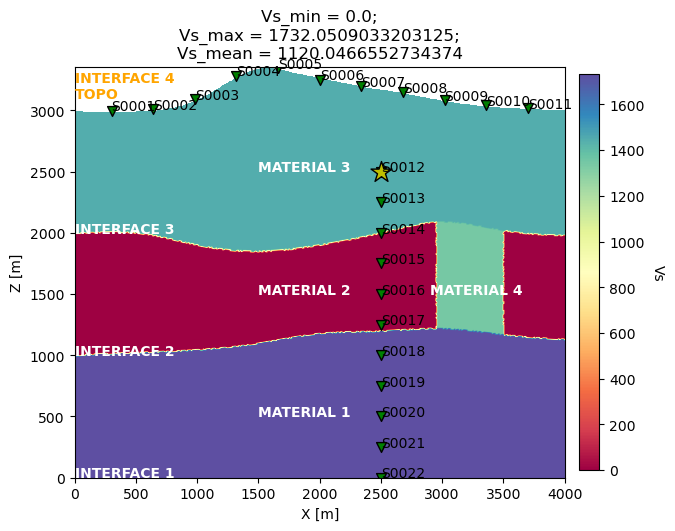

In [21]:
def plot_velocity_model():
    """Convenience function to plot velocity model with sources and stations"""
    # Grab STATION coordinates by reading ACSII files
    sta_x, sta_z = np.genfromtxt("DATA/STATIONS", dtype=float, usecols=[2, 3]).T
    sta_id = np.genfromtxt("DATA/STATIONS", dtype=str, usecols=[0]).T

    # Grab SOURCE coordinates from SOURCE file
    source_file = f"DATA/SOURCE"
    with open(source_file, "r") as f:
        lines = f.readlines()

    # Trying to break apart the following line
    # 'xs = 299367.72      # source location x in meters\n'
    ev_x = float(lines[2].split("=")[1].split("#")[0].strip())
    ev_z = float(lines[3].split("=")[1].split("#")[0].strip())

    # Use SeisFlows 'Model' class to plot the 2D model 
    m = Model(path="DATA")
    m.plot2d(parameter="vs", show=False)

    # Plot SOURCE and STATIONS on top of the model
    for x_, z_, id_ in zip(sta_x, sta_z, sta_id):
        plt.scatter(float(x_), float(z_), c="g", marker="v", ec="k", s=50)
        plt.text(x_, z_, id_)
    plt.scatter(ev_x, ev_z, c="y", marker="*", ec="k", s=250)
    
    # Plot interface text labels for educational purposes
    plt.text(0, 0, "INTERFACE 1", c="w", weight="bold", size=10)
    plt.text(0, 1000, "INTERFACE 2", c="w", weight="bold", size=10)
    plt.text(0, 2000, "INTERFACE 3", c="w", weight="bold", size=10)
    plt.text(0, 3100, "INTERFACE 4\nTOPO", c="orange", weight="bold", size=10)
    
    # Plot material text labels for educational purposes
    plt.text(1500, 500, "MATERIAL 1", c="w", weight="bold", size=10)
    plt.text(1500, 1500, "MATERIAL 2", c="w", weight="bold", size=10)
    plt.text(1500, 2500, "MATERIAL 3", c="w", weight="bold", size=10)
    plt.text(2900, 1500, "MATERIAL 4", c="w", weight="bold", size=10)
    
plot_velocity_model()

In [22]:
# We can compare the interface file with the mesh above
! head -39 EXAMPLES/simple_topography_and_also_a_simple_fluid_layer/DATA/interfaces_simple_topo_curved.dat | tail -n 34

# interface number 1 (bottom of the mesh)
 2
 0 0
 5000 0
# interface number 2
 7
    0 1000
 1500 1100
 2000 1180
 2500 1200
 3000 1220
 3500 1170
 5000 1100
# interface number 3
 9
    0 2000
  500 2000
 1000 1900
 1500 1847
 2000 1900
 2500 2000
 3000 2090
 3500 2020
 5000 2000
# interface number 4 (topography, top of the mesh)
 8
    0 3000
  500 3000
 1000 3100
 1500 3350
 2000 3250
 2500 3180
 3000 3090
 5000 3000


In [23]:
# We have generated synthetics for each station location shown above
! ls OUTPUT_FILES/*.semd
! echo

# The first 10 lines of a seismogram show the two-column (time, amplitude) format
! head -10 OUTPUT_FILES/AA.S0001.BXX.semd

OUTPUT_FILES/AA.S0001.BXX.semd	OUTPUT_FILES/AA.S0012.BXX.semd
OUTPUT_FILES/AA.S0001.BXZ.semd	OUTPUT_FILES/AA.S0012.BXZ.semd
OUTPUT_FILES/AA.S0002.BXX.semd	OUTPUT_FILES/AA.S0013.BXX.semd
OUTPUT_FILES/AA.S0002.BXZ.semd	OUTPUT_FILES/AA.S0013.BXZ.semd
OUTPUT_FILES/AA.S0003.BXX.semd	OUTPUT_FILES/AA.S0014.BXX.semd
OUTPUT_FILES/AA.S0003.BXZ.semd	OUTPUT_FILES/AA.S0014.BXZ.semd
OUTPUT_FILES/AA.S0004.BXX.semd	OUTPUT_FILES/AA.S0015.BXX.semd
OUTPUT_FILES/AA.S0004.BXZ.semd	OUTPUT_FILES/AA.S0015.BXZ.semd
OUTPUT_FILES/AA.S0005.BXX.semd	OUTPUT_FILES/AA.S0016.BXX.semd
OUTPUT_FILES/AA.S0005.BXZ.semd	OUTPUT_FILES/AA.S0016.BXZ.semd
OUTPUT_FILES/AA.S0006.BXX.semd	OUTPUT_FILES/AA.S0017.BXX.semd
OUTPUT_FILES/AA.S0006.BXZ.semd	OUTPUT_FILES/AA.S0017.BXZ.semd
OUTPUT_FILES/AA.S0007.BXX.semd	OUTPUT_FILES/AA.S0018.BXX.semd
OUTPUT_FILES/AA.S0007.BXZ.semd	OUTPUT_FILES/AA.S0018.BXZ.semd
OUTPUT_FILES/AA.S0008.BXX.semd	OUTPUT_FILES/AA.S0019.BXX.semd
OUTPUT_FILES/AA.S0008.BXZ.semd	OUTPUT_FILES/AA.S0019.BXZ.semd
OUTPUT_F

Text(0, 0.5, 'Displacement [m]')

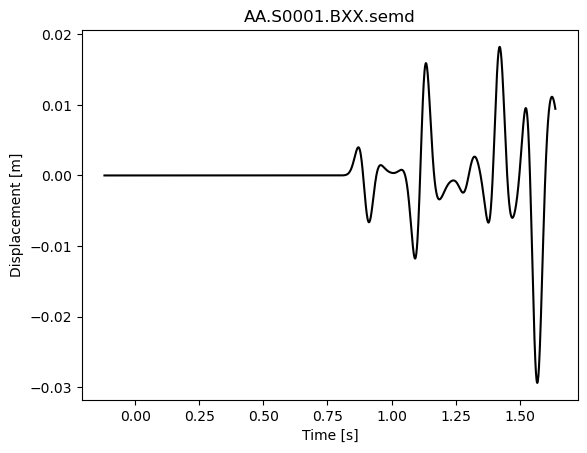

In [24]:
# Plot seismograms using NumPy and Matplotlib
data = np.loadtxt("OUTPUT_FILES/AA.S0001.BXX.semd", dtype=float)

plt.plot(data[:,0], data[:,1], c="k")
plt.title("AA.S0001.BXX.semd")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")

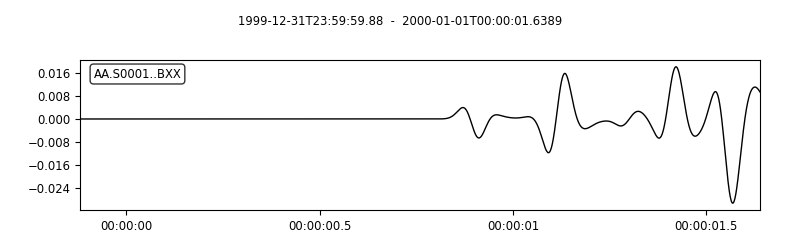

In [25]:
# SeisFlows also has a simple command line tool to plot seismograms using ObsPy
! seisflows plotst OUTPUT_FILES/AA.S0001.BXX.semd --savefig AA.S0001.BXX.semd.png
Image("AA.S0001.BXX.semd.png")

[2026-02-18 22:38:05] - pysep - INFO: starting record section plotter
[2026-02-18 22:38:05] - pysep - INFO: attempting to read 122 'syn' files from: OUTPUT_FILES/
[2026-02-18 22:38:05] - pysep - WARNING: unexpected read error OUTPUT_FILES/error_message000000.txt: 
[2026-02-18 22:38:05] - pysep - WARNING: unexpected read error OUTPUT_FILES/output_meshfem2d.txt: 
[2026-02-18 22:38:05] - pysep - WARNING: unexpected read error OUTPUT_FILES/Database00000.bin: 'utf-8' codec can't decode byte 0xf7 in position 552: invalid start byte
[2026-02-18 22:38:05] - pysep - WARNING: unexpected read error OUTPUT_FILES/Database00001.bin: 'utf-8' codec can't decode byte 0xf3 in position 540: invalid continuation byte
[2026-02-18 22:38:05] - pysep - WARNING: unexpected read error OUTPUT_FILES/Database00002.bin: 'utf-8' codec can't decode byte 0xff in position 540: invalid start byte
[2026-02-18 22:38:05] - pysep - WARNING: unexpected read error OUTPUT_FILES/Database00003.bin: 'utf-8' codec can't decode byt

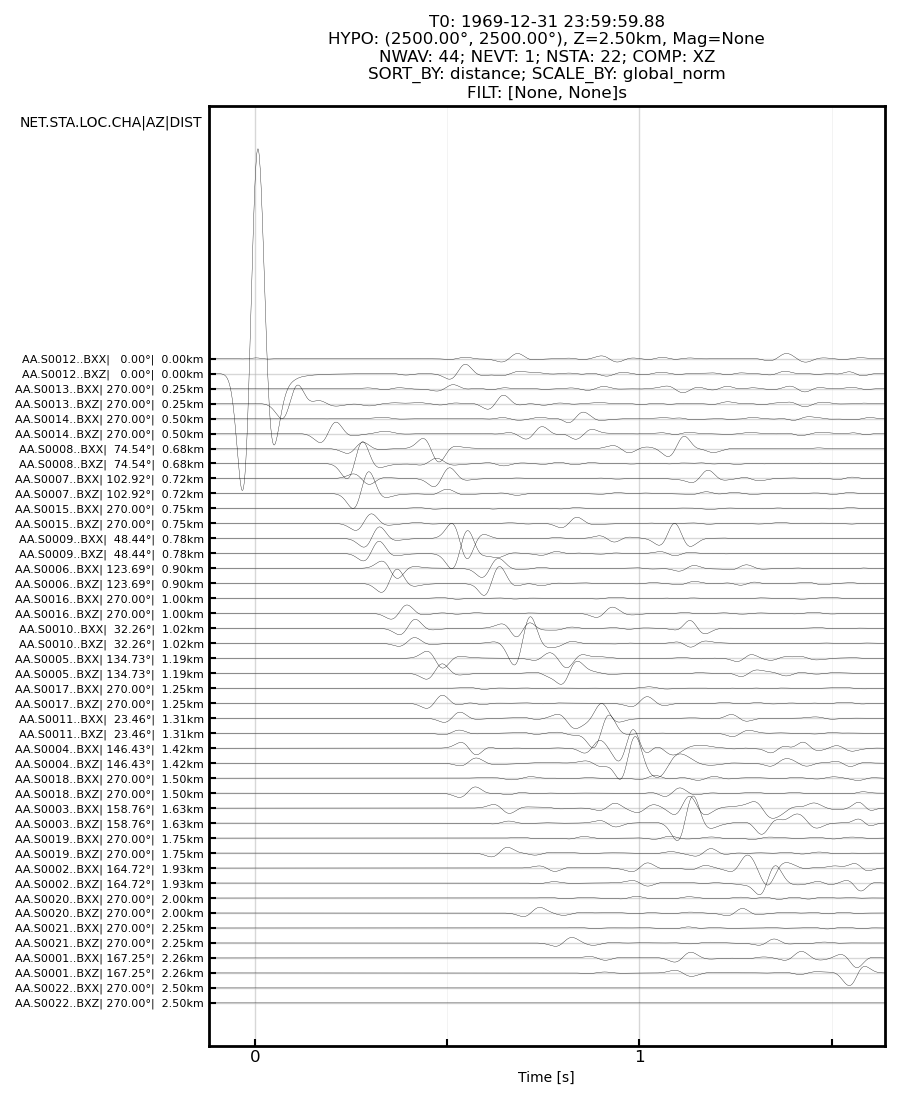

In [26]:

# We can use PySEP's record section (RecSec) tool to plot SPECFEM2D synthetics
# Note: because SPECFEM2D's SOURCE files don't contain origin time information, RecSec uses a dummy time
! recsec --syn_path OUTPUT_FILES/ --source DATA/SOURCE --stations DATA/STATIONS \
    --components XZ --scale_by global_norm --amplitude_scale_factor 15 \
    --xtick_major=1 --overwrite -L INFO

Image("record_section.png")

In [27]:
# Use sempar to display parameter values
! seisflows sempar -P DATA/Par_file ntstep_between_output_images
! seisflows sempar -P DATA/Par_file dt

NTSTEP_BETWEEN_OUTPUT_IMAGES: 100
DT: 0.0011


In [28]:
# Wavefield snapshots every 100 time steps
! ls OUTPUT_FILES/*.jpg

OUTPUT_FILES/forward_image000000005.jpg
OUTPUT_FILES/forward_image000000100.jpg
OUTPUT_FILES/forward_image000000200.jpg
OUTPUT_FILES/forward_image000000300.jpg
OUTPUT_FILES/forward_image000000400.jpg
OUTPUT_FILES/forward_image000000500.jpg
OUTPUT_FILES/forward_image000000600.jpg
OUTPUT_FILES/forward_image000000700.jpg
OUTPUT_FILES/forward_image000000800.jpg
OUTPUT_FILES/forward_image000000900.jpg
OUTPUT_FILES/forward_image000001000.jpg
OUTPUT_FILES/forward_image000001100.jpg
OUTPUT_FILES/forward_image000001200.jpg
OUTPUT_FILES/forward_image000001300.jpg
OUTPUT_FILES/forward_image000001400.jpg
OUTPUT_FILES/forward_image000001500.jpg
OUTPUT_FILES/forward_image000001600.jpg


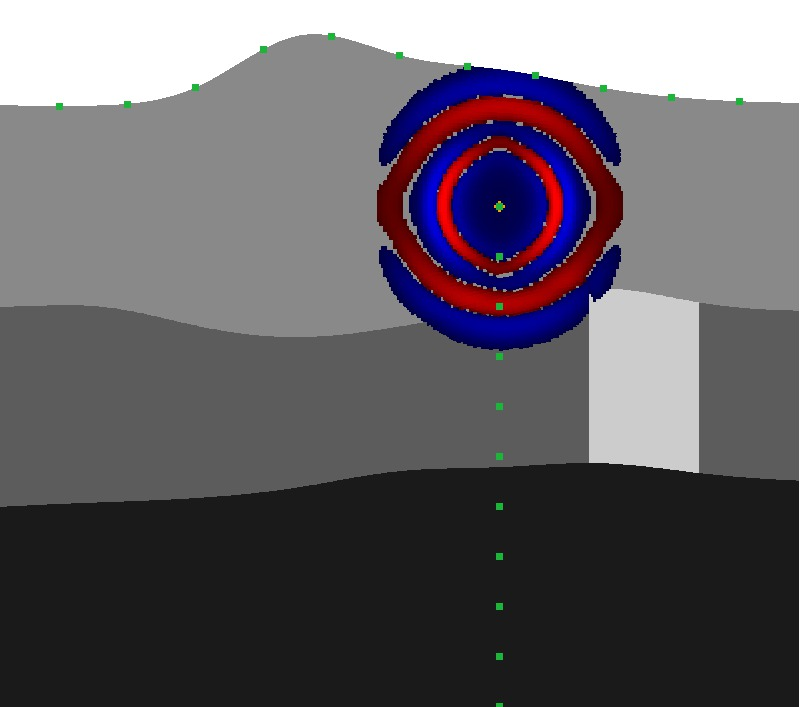

In [29]:

Image("OUTPUT_FILES/forward_image000000300.jpg")

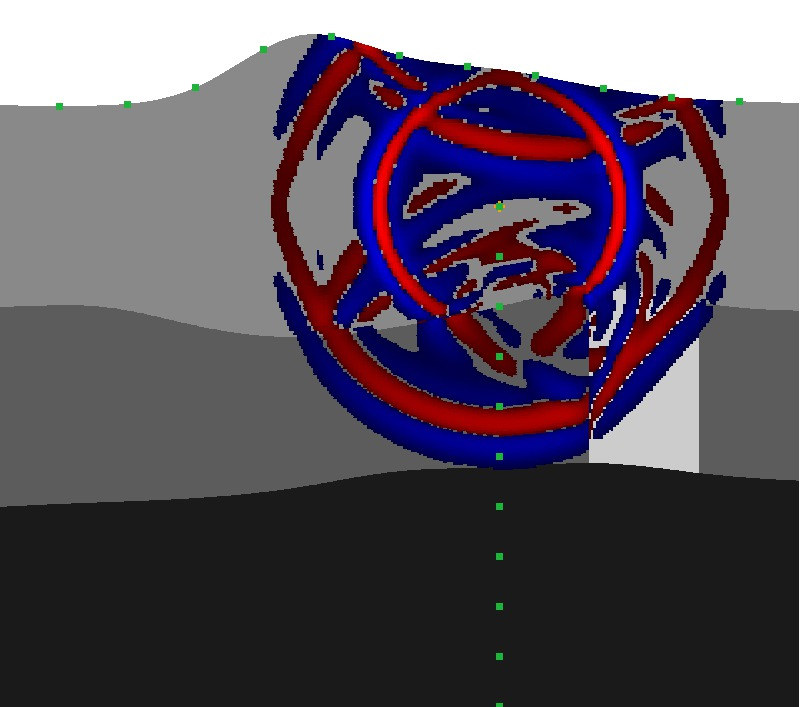

In [30]:
Image("OUTPUT_FILES/forward_image000000500.jpg")

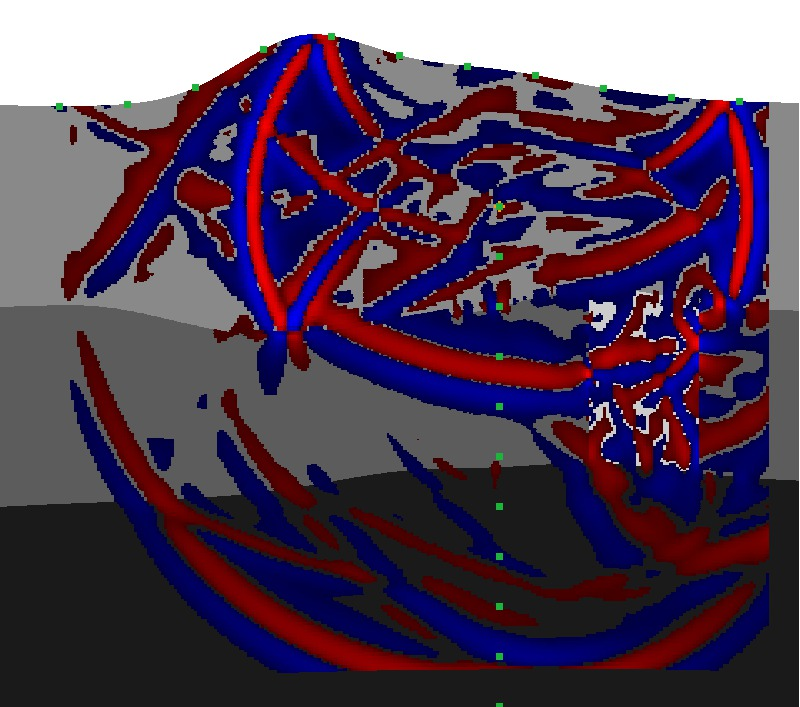

In [31]:

Image("OUTPUT_FILES/forward_image000000900.jpg")